<a href="https://colab.research.google.com/github/azhar8976/gzme_/blob/main/Machine_Learning_House_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/House_Price_prediction dataset.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
df.shape

(4600, 18)

In [5]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [6]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [7]:
c_col = df.select_dtypes(include=["object"]).columns
x_enc = pd.get_dummies(df, columns=c_col, drop_first=True)

In [8]:
x_enc = x_enc.astype(int)
x_enc

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,313000,3,1,1340,7912,1,0,0,3,1340,...,0,0,0,0,0,0,0,0,0,0
1,2384000,5,2,3650,9050,2,0,4,5,3370,...,0,0,0,0,0,0,0,0,0,0
2,342000,3,2,1930,11947,1,0,0,4,1930,...,0,0,0,0,0,0,0,0,0,0
3,420000,3,2,2000,8030,1,0,0,4,1000,...,0,0,0,0,0,0,0,0,0,0
4,550000,4,2,1940,10500,1,0,0,4,1140,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,308166,3,1,1510,6360,1,0,0,4,1510,...,0,0,0,0,0,0,0,0,0,0
4596,534333,3,2,1460,7573,2,0,0,3,1460,...,0,0,0,0,0,0,0,0,0,0
4597,416904,3,2,3010,7014,2,0,0,3,3010,...,0,0,0,0,0,0,0,0,0,0
4598,203400,4,2,2090,6630,1,0,0,3,1070,...,0,0,0,0,1,0,0,0,0,0


#Numerical Columns

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_10556/2273551273.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


# Categorical Columns

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_10556/2213161713.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [11]:
pd.get_dummies(df)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354,country_USA
0,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,False,False,False,False,False,False,False,False,False,True
1,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,False,False,True
2,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,False,False,True
3,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,False,False,True
4,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,...,False,False,False,False,False,False,False,False,False,True
4596,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,...,False,False,False,False,False,False,False,False,False,True
4597,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,...,False,False,False,False,False,False,False,False,False,True
4598,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,...,False,False,False,True,False,False,False,False,False,True


In [12]:
data = {
    'City': ['Delhi', 'Mumbai', 'Delhi', 'Chennai'],
    'Gender': ['Male', 'Female', 'Female', 'Male'],
    'Age': [21, 22, 23, 24]
}

df = pd.DataFrame(data)

print(df)

      City  Gender  Age
0    Delhi    Male   21
1   Mumbai  Female   22
2    Delhi  Female   23
3  Chennai    Male   24


In [13]:
df_encoded = pd.get_dummies(df)

print(df_encoded)

   Age  City_Chennai  City_Delhi  City_Mumbai  Gender_Female  Gender_Male
0   21         False        True        False          False         True
1   22         False       False         True           True        False
2   23         False        True        False           True        False
3   24          True       False        False          False         True


In [14]:
df_encoded = pd.get_dummies(df, dtype=int)

print(df_encoded)

   Age  City_Chennai  City_Delhi  City_Mumbai  Gender_Female  Gender_Male
0   21             0           1            0              0            1
1   22             0           0            1              1            0
2   23             0           1            0              1            0
3   24             1           0            0              0            1


In [15]:
# Categorical columns check
cat_cols = df.select_dtypes(include=['object']).columns

print(cat_cols)

Index(['City', 'Gender'], dtype='object')


In [16]:
df_encoded = pd.get_dummies(df, columns=cat_cols, dtype=int)

print(df_encoded.head())

   Age  City_Chennai  City_Delhi  City_Mumbai  Gender_Female  Gender_Male
0   21             0           1            0              0            1
1   22             0           0            1              1            0
2   23             0           1            0              1            0
3   24             1           0            0              0            1


In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,City,Gender,Age
0,1,1,21
1,2,0,22
2,1,0,23
3,0,1,24


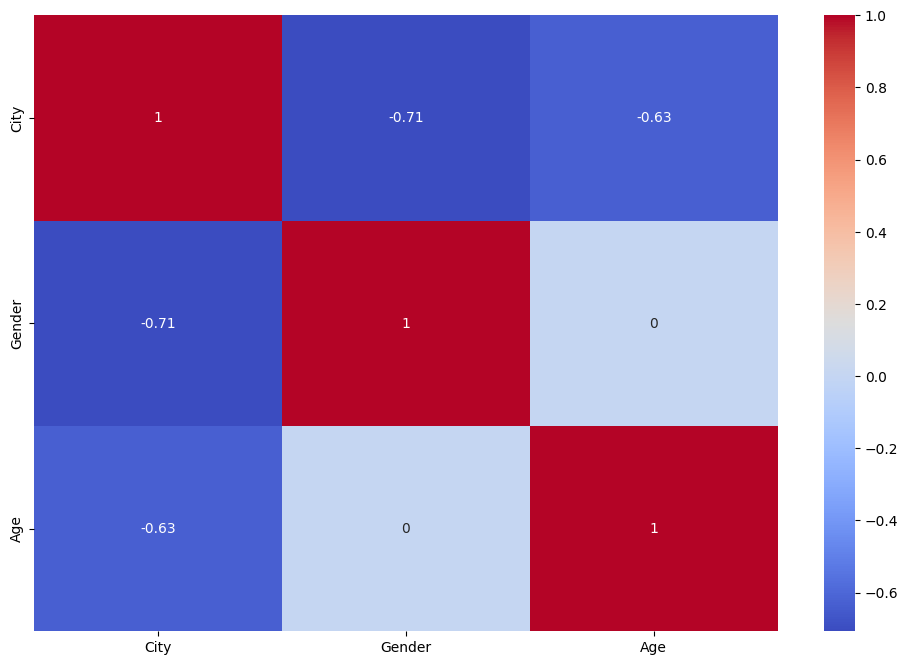

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

In [19]:
print(df.columns)

Index(['City', 'Gender', 'Age'], dtype='object')


In [20]:
target = 'price'

In [21]:
X = x_enc.drop(target, axis=1)

y = x_enc[target]

print(X.head())
print(y.head())

   bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0         3          1         1340      7912       1           0     0   
1         5          2         3650      9050       2           0     4   
2         3          2         1930     11947       1           0     0   
3         3          2         2000      8030       1           0     0   
4         4          2         1940     10500       1           0     0   

   condition  sqft_above  sqft_basement  ...  statezip_WA 98155  \
0          3        1340              0  ...                  0   
1          5        3370            280  ...                  0   
2          4        1930              0  ...                  0   
3          4        1000           1000  ...                  0   
4          4        1140            800  ...                  0   

   statezip_WA 98166  statezip_WA 98168  statezip_WA 98177  statezip_WA 98178  \
0                  0                  0                  0       

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (3680, 4724)
Testing Data Shape: (920, 4724)


In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [24]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 521922.72109679  348558.87239404 1286236.83791377  -12618.96265145
  457106.65643264  456920.66825245  476107.86324206  308280.98195067
  526660.09949916  582834.38072717]


In [25]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 300665.8022438598


In [26]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1155496229151.8132


In [27]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 1074940.1049136706


In [28]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: -0.1330101206587302


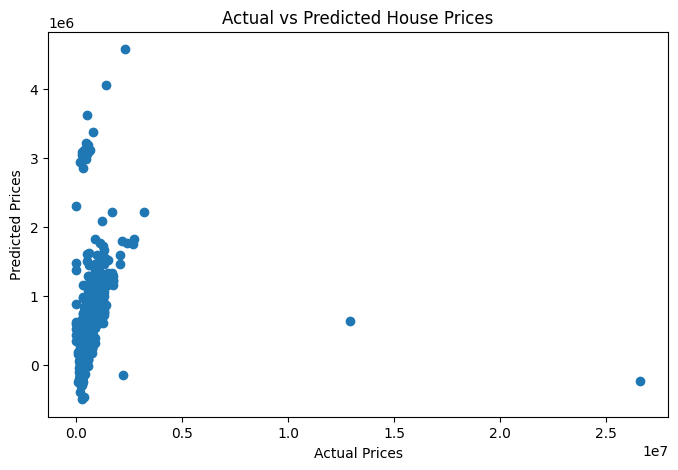

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [30]:
print(X.columns)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       ...
       'statezip_WA 98155', 'statezip_WA 98166', 'statezip_WA 98168',
       'statezip_WA 98177', 'statezip_WA 98178', 'statezip_WA 98188',
       'statezip_WA 98198', 'statezip_WA 98199', 'statezip_WA 98288',
       'statezip_WA 98354'],
      dtype='object', length=4724)


In [31]:
# The model was trained on many features, including one-hot encoded categorical features.
# The new_house input must have the same feature structure as X.

# First, define the new house's features in the original format (before one-hot encoding).
# Replace these with actual meaningful values for a new house you want to predict.
# These values should reflect the categories present in the training data.
new_house_original_data = {
    'date': '2014-05-02 00:00:00', # Example date string (must match format in training data)
    'bedrooms': 3.0,
    'bathrooms': 2.0,
    'sqft_living': 1500,
    'sqft_lot': 5000,
    'floors': 1.0,
    'waterfront': 0,
    'view': 0,
    'condition': 3,
    'sqft_above': 1500,
    'sqft_basement': 0,
    'yr_built': 1990,
    'yr_renovated': 0,
    'street': '18810 Densmore Ave N', # Example street from training data
    'city': 'Shoreline',   # Example city from training data
    'statezip': 'WA 98133', # Example statezip from training data
    'country': 'USA' # Example country from training data
}

# Create a DataFrame from these original features
new_house_df_prep = pd.DataFrame([new_house_original_data])

# Identify categorical columns that were one-hot encoded in the original dataset.
# Based on cell `td4NNvGgTyda` and `bCDBlaG9TIbz`, these were 'date', 'street', 'city', 'statezip', 'country'.
categorical_cols_for_encoding = ['date', 'street', 'city', 'statezip', 'country']

# One-hot encode the new house data
new_house_enc = pd.get_dummies(new_house_df_prep, columns=categorical_cols_for_encoding, drop_first=True)

# Convert boolean columns created by get_dummies to int type, for consistency with X
for col in new_house_enc.select_dtypes(include=['bool']).columns:
    new_house_enc[col] = new_house_enc[col].astype(int)

# Ensure the new_house_enc DataFrame has all columns present in X (the training features)
# and in the same order, filling missing one-hot encoded columns with 0.
missing_cols = list(set(X.columns) - set(new_house_enc.columns))
if missing_cols:
    missing_df = pd.DataFrame(0, index=new_house_enc.index, columns=missing_cols)
    new_house_enc = pd.concat([new_house_enc, missing_df], axis=1)

# Ensure the order of columns in new_house_enc matches the order in X
new_house_df_final = new_house_enc[X.columns]

# Now predict with the properly formatted new house features
prediction = model.predict(new_house_df_final)

print("Predicted House Price:", prediction)


Predicted House Price: [-37939.5258781]


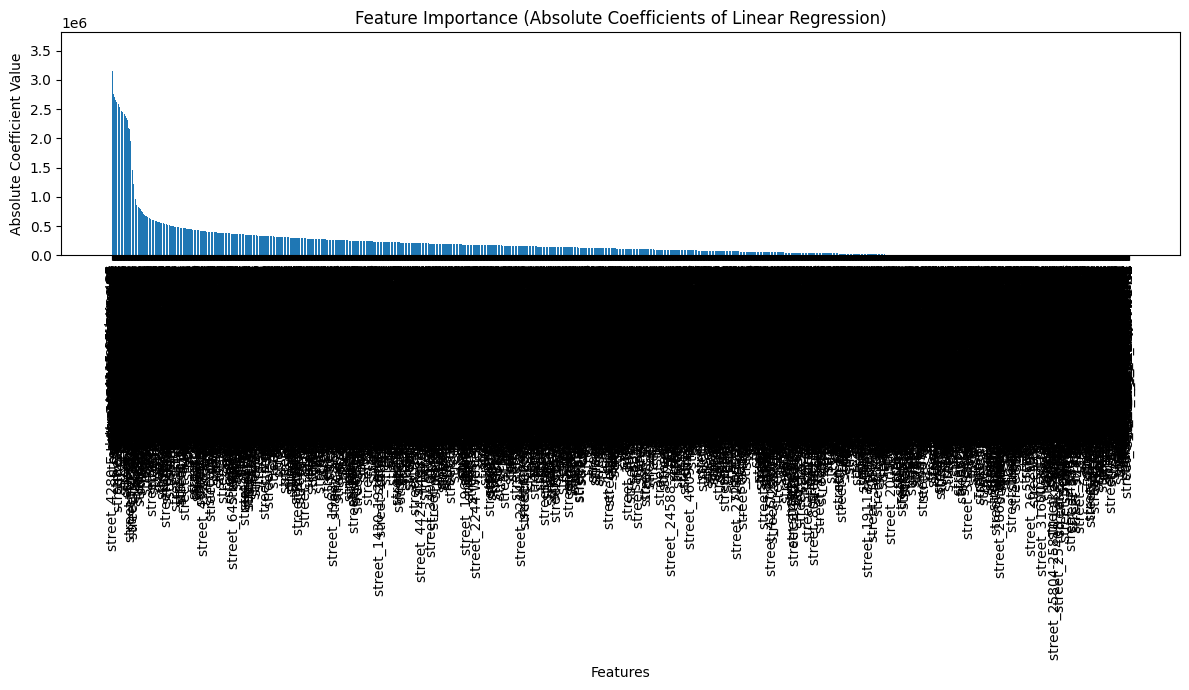

In [32]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
})

feature_importance['Importance'] = np.abs(feature_importance['Importance'])
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Absolute Coefficient Value')
plt.title('Feature Importance (Absolute Coefficients of Linear Regression)')
plt.tight_layout()
plt.show()

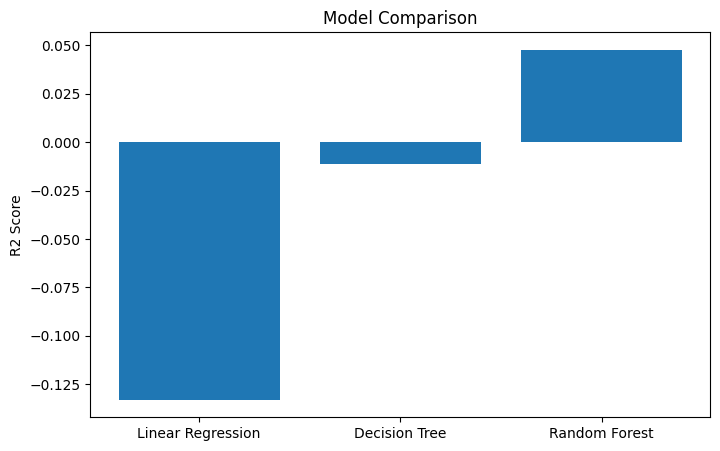

In [33]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Train Decision Tree Model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Train Random Forest Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

models = ['Linear Regression',
          'Decision Tree',
          'Random Forest']

scores = [
    r2_score(y_test, y_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred)
]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

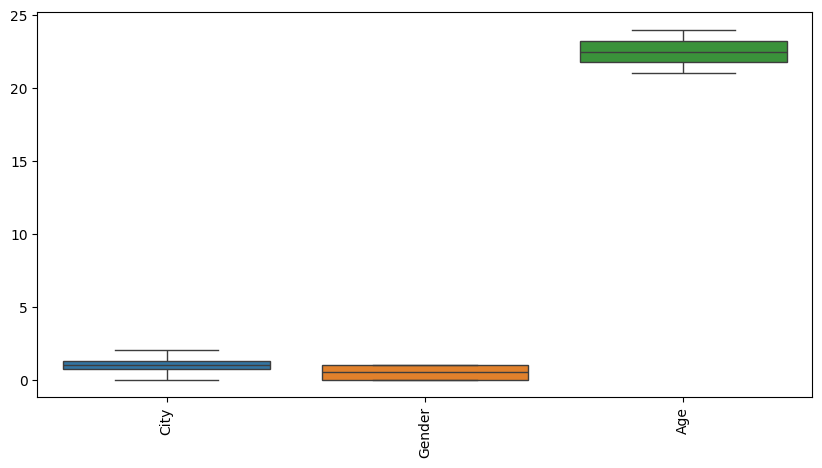

In [34]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [36]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print(scores)

print("Average Score:", scores.mean())

[0.7075384  0.72628573 0.66838783 0.66570731 0.03390335]
Average Score: 0.5603645233690491


In [37]:
from sklearn.model_selection import GridSearchCV

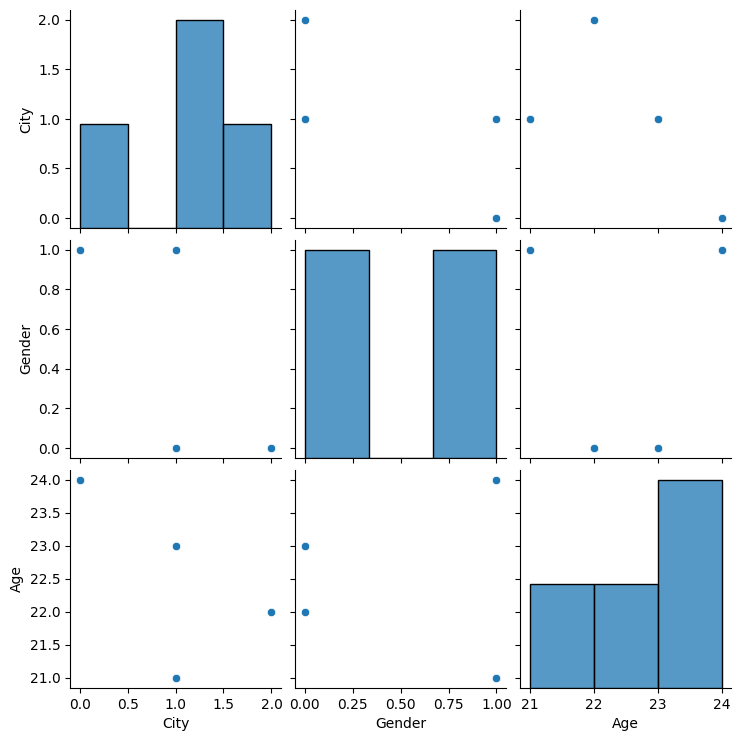

In [38]:
sns.pairplot(df)

plt.show()

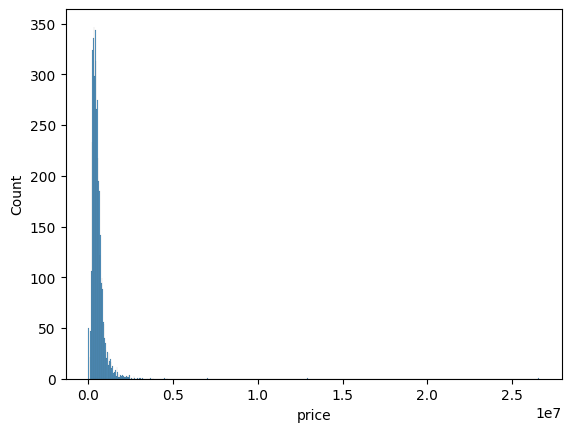

In [44]:
sns.histplot(x_enc['price'])

plt.show()

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   City    4 non-null      int64
 1   Gender  4 non-null      int64
 2   Age     4 non-null      int64
dtypes: int64(3)
memory usage: 228.0 bytes


In [46]:
df

,City,Gender,Age
0,1,1,21
1,2,0,22
2,1,0,23
3,0,1,24
